# 00 — Setup & Tools: PySCF, ASE, py3Dmol, and Visualization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/00_setup_and_tools.ipynb)

## 🎯 Learning Objectives

- Install and verify all required packages (PySCF, ASE, py3Dmol, cclib)
- Run a basic Hartree-Fock calculation with PySCF on a small molecule
- Manipulate molecular structures using ASE
- Visualize molecules in 3D with py3Dmol
- Parse quantum chemistry output files with cclib
- Understand the overall computational chemistry workflow

In [1]:
# =============================================================================
# Ch121a: Quantum Chemistry & DFT — Notebook 00: Setup & Tools
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)
# =============================================================================
# Install required packages (run this cell first, especially on Google Colab)
import subprocess, sys

packages = ['pyscf', 'ase', 'py3Dmol', 'nglview', 'cclib', 'matplotlib',
            'numpy', 'pandas', 'scipy', 'seaborn', 'ipywidgets']

for pkg in packages:
    try:
        __import__(pkg.replace('-','_').split('>=')[0])
        print(f"✓ {pkg} already installed")
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
        print(f"✓ {pkg} installed")

✓ pyscf already installed
✓ ase already installed
✓ py3Dmol already installed


✓ nglview already installed
✓ cclib already installed
✓ matplotlib already installed
✓ numpy already installed
✓ pandas already installed
✓ scipy already installed
✓ seaborn already installed
✓ ipywidgets already installed


In [2]:
# ------------------------------------------------------------------
# Running a Hartree-Fock calculation with PySCF
# ------------------------------------------------------------------
# PySCF is a quantum chemistry package written entirely in Python.
# It supports HF, DFT, MP2, CCSD, and many other methods.

from pyscf import gto, scf
import numpy as np

# Step 1: Define the molecular structure
mol = gto.Mole()
mol.atom = '''
O   0.000000   0.000000   0.117176
H   0.000000   0.757001  -0.468704
H   0.000000  -0.757001  -0.468704
'''
mol.basis = 'STO-3G'   # Minimal basis set — fast but not very accurate
mol.charge = 0         # Neutral molecule
mol.spin = 0           # Singlet (2S = 0, all electrons paired)
mol.verbose = 0        # Suppress output (set to 3 or 4 for detailed output)
mol.build()            # Build the molecular object (computes integrals)

print(f"Molecule: water (H₂O)")
print(f"Number of atoms:             {mol.natm}")
print(f"Number of electrons:         {mol.nelectron}")
print(f"Number of basis functions:   {mol.nao_nr()}")

# Step 2: Set up and run a Restricted Hartree-Fock (RHF) calculation
mf = scf.RHF(mol)
mf.verbose = 0         # Suppress SCF convergence output
energy = mf.kernel()   # Run the SCF procedure

print(f"\nRHF/STO-3G Results:")
print(f"  Total HF energy:   {energy:.8f} Hartree")
print(f"  Total HF energy:   {energy * 27.2114:.4f} eV")

# Step 3: Analyze molecular orbital energies
mo_energies = mf.mo_energy     # Orbital energies in Hartree
mo_occ = mf.mo_occ             # Orbital occupancies (0 or 2 for RHF)

homo_idx = np.where(mo_occ > 0)[0][-1]
lumo_idx = homo_idx + 1

print(f"\nMolecular Orbital Energies (eV):")
for i, (e, occ) in enumerate(zip(mo_energies, mo_occ)):
    label = ""
    if i == homo_idx:
        label = " ← HOMO"
    elif i == lumo_idx:
        label = " ← LUMO"
    status = "occupied" if occ > 0 else "virtual"
    print(f"  MO {i+1:2d} ({status:8s}): {e*27.2114:8.3f} eV{label}")

print(f"\nHOMO energy: {mo_energies[homo_idx]*27.2114:.3f} eV")
print(f"LUMO energy: {mo_energies[lumo_idx]*27.2114:.3f} eV")
print(f"HOMO-LUMO gap: {(mo_energies[lumo_idx]-mo_energies[homo_idx])*27.2114:.3f} eV")

Molecule: water (H₂O)
Number of atoms:             3
Number of electrons:         10
Number of basis functions:   7

RHF/STO-3G Results:
  Total HF energy:   -74.96293261 Hartree
  Total HF energy:   -2039.8463 eV

Molecular Orbital Energies (eV):
  MO  1 (occupied): -550.806 eV
  MO  2 (occupied):  -34.515 eV
  MO  3 (occupied):  -16.814 eV
  MO  4 (occupied):  -12.326 eV
  MO  5 (occupied):  -10.646 eV ← HOMO
  MO  6 (virtual ):   16.480 eV ← LUMO
  MO  7 (virtual ):   20.201 eV

HOMO energy: -10.646 eV
LUMO energy: 16.480 eV
HOMO-LUMO gap: 27.126 eV


In [8]:
# ------------------------------------------------------------------
# Working with molecular structures using ASE
# ------------------------------------------------------------------
# ASE (Atomic Simulation Environment) provides tools for building,
# manipulating, and analyzing molecular and periodic structures.

from ase.build import molecule
from ase.io import write
import numpy as np

# Build a water molecule from the G2 database
water = molecule('H2O')

print("ASE Atoms object for water (H₂O):")
print(f"  Formula:          {water.get_chemical_formula()}")
print(f"  Number of atoms:  {len(water)}")
print(f"  Atomic numbers:   {water.get_atomic_numbers()}")
print(f"  Chemical symbols: {water.get_chemical_symbols()}")

print("\nAtomic positions (Angstrom):")
print(f"  {'Symbol':6s}  {'x':>10s}  {'y':>10s}  {'z':>10s}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}")
for atom in water:
    print(f"  {atom.symbol:6s}  {atom.x:10.6f}  {atom.y:10.6f}  {atom.z:10.6f}")

# Compute bond lengths
from itertools import combinations
print("\nBond lengths:")
positions = water.get_positions()
symbols = water.get_chemical_symbols()
for (i, j) in combinations(range(len(water)), 2):
    dist = np.linalg.norm(positions[i] - positions[j])
    print(f"  {symbols[i]}-{symbols[j]}: {dist:.4f} Å")

# ASE can build many common molecules
print("\nOther molecules available in ASE:")
for mol_name in ['NH3', 'CH4', 'CO2', 'C6H6', 'HF']:
    m = molecule(mol_name)
    print(f"  {mol_name:6s}: {len(m)} atoms, formula = {m.get_chemical_formula()}")

ASE Atoms object for water (H₂O):
  Formula:          H2O
  Number of atoms:  3
  Atomic numbers:   [8 1 1]
  Chemical symbols: ['O', 'H', 'H']

Atomic positions (Angstrom):
  Symbol           x           y           z
  ------  ----------  ----------  ----------
  O         0.000000    0.000000    0.119262
  H         0.000000    0.763239   -0.477047
  H         0.000000   -0.763239   -0.477047

Bond lengths:
  O-H: 0.9686 Å
  O-H: 0.9686 Å
  H-H: 1.5265 Å

Other molecules available in ASE:
  NH3   : 4 atoms, formula = H3N
  CH4   : 5 atoms, formula = CH4
  CO2   : 3 atoms, formula = CO2
  C6H6  : 12 atoms, formula = C6H6
  HF    : 2 atoms, formula = HF


In [9]:
# ------------------------------------------------------------------
# 3D molecular visualization with py3Dmol
# ------------------------------------------------------------------
import py3Dmol

# Water molecule in XYZ format
water_xyz = """3
Water molecule (H2O) - B3LYP/def2-SVP optimized geometry
O   0.000000   0.000000   0.117176
H   0.000000   0.757001  -0.468704
H   0.000000  -0.757001  -0.468704
"""

# Create a 3D viewer
view = py3Dmol.view(width=500, height=400)

# Add the molecule from XYZ format
view.addModel(water_xyz, 'xyz')

# Style the molecule: ball-and-stick representation
view.setStyle({'stick': {'radius': 0.15}, 'sphere': {'scale': 0.3}})

# Add labels for each atom
view.addLabel('O', {'position': {'x': 0, 'y': 0, 'z': 0.117176},
                    'fontSize': 14, 'fontColor': 'red',
                    'backgroundColor': 'white', 'backgroundOpacity': 0.7})

# Set background and zoom
view.setBackgroundColor('white')
view.zoomTo()
view.show()
print("3D visualization of water (H₂O)")
print("Tip: Click and drag to rotate, scroll to zoom.")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3D visualization of water (H₂O)
Tip: Click and drag to rotate, scroll to zoom.


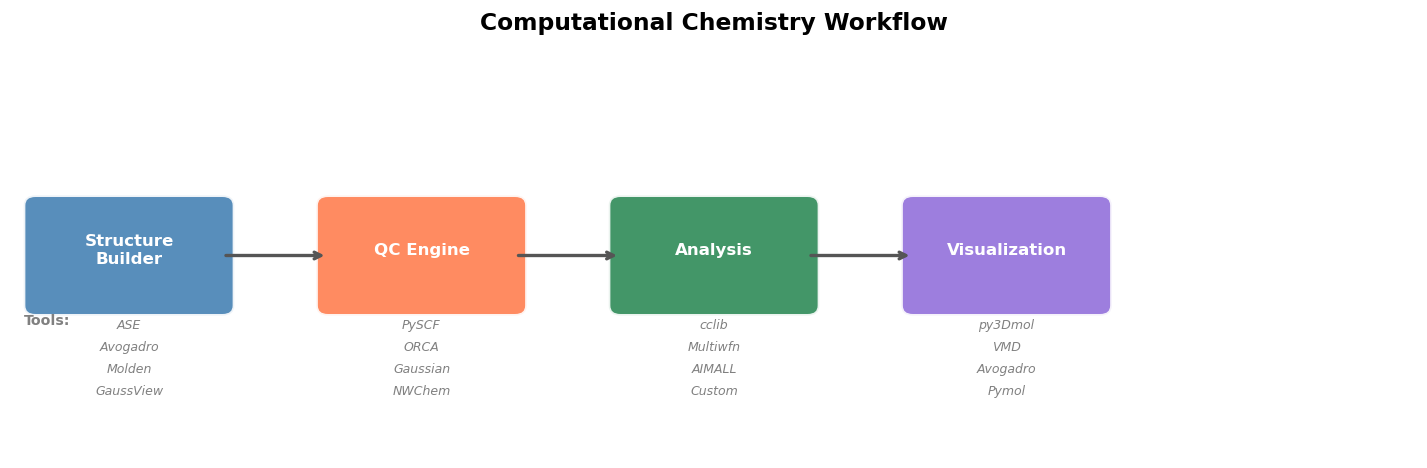

In [12]:
# ------------------------------------------------------------------
# Computational Chemistry Workflow Diagram
# ------------------------------------------------------------------
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis('off')

# Workflow steps
steps = [
    ('Structure\nBuilder', 1.0, 'steelblue',
     ['ASE', 'Avogadro', 'Molden', 'GaussView']),
    ('QC Engine', 3.5, 'coral',
     ['PySCF', 'ORCA', 'Gaussian', 'NWChem']),
    ('Analysis', 6.0, 'seagreen',
     ['cclib', 'Multiwfn', 'AIMALL', 'Custom']),
    ('Visualization', 8.5, 'mediumpurple',
     ['py3Dmol', 'VMD', 'Avogadro', 'Pymol'])
]

for (label, x, color, tools) in steps:
    # Draw box
    box = mpatches.FancyBboxPatch((x-0.8, 1.5), 1.6, 1.0,
                                   boxstyle="round,pad=0.1",
                                   facecolor=color, edgecolor='white',
                                   linewidth=2, alpha=0.9)
    ax.add_patch(box)
    ax.text(x, 2.05, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    # Tools below
    for j, tool in enumerate(tools):
        ax.text(x, 1.3 - j*0.22, tool, ha='center', va='center',
                fontsize=7.5, color='gray', style='italic')

# Arrows between boxes
for i in range(len(steps)-1):
    x1 = steps[i][1] + 0.8
    x2 = steps[i+1][1] - 0.8
    ax.annotate('', xy=(x2, 2.0), xytext=(x1, 2.0),
                arrowprops=dict(arrowstyle='->', color='#555', lw=2))

# Labels row headers
ax.text(0.1, 2.05, '', ha='left', va='center', fontsize=9, color='#333')
ax.text(0.1, 1.35, 'Tools:', ha='left', va='center', fontsize=8.5,
        color='gray', fontweight='bold')

ax.set_title('Computational Chemistry Workflow', fontsize=14,
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 🔬 
Modern quantum chemistry software like PySCF and ORCA is used in:

- **Drug discovery**: Computing binding affinities, reaction mechanisms in enzyme active sites
- **Materials science**: Predicting electronic properties of new solar cell materials
- **Catalysis**: Understanding transition metal catalytic cycles (Nobel Prize 2022: click chemistry)
- **Astrochemistry**: Modeling interstellar molecular spectra for telescope identification

The Python ecosystem (PySCF + ASE + cclib + py3Dmol) enables fully reproducible,
scriptable workflows — essential for modern computational science.

**Key papers:**
- Sun et al., *WIREs Comput. Mol. Sci.* **8**, e1340 (2018) — PySCF
- Larsen et al., *J. Phys.: Condens. Matter* **29**, 273002 (2017) — ASE

## 📝 Exercises
Note: Use the best suitable approach. On HPC, ORCA can also be used to run these calculations. In that case, you would need to copy coordinates from above cells, or generate with Avogadro(preferably v2), and use job submission script, and a sample input script kept in '../Initialization' directory.

1. **Basis set effect**: Modify the PySCF cell to use `6-31G*` instead of `STO-3G`. 
   How does the total energy and HOMO-LUMO gap change?

2. **Different molecule**: Replace water with NH₃ (ammonia). 
   - Atom string: `N 0 0 0; H 0.94 0 0; H -0.47 0.82 0; H -0.47 -0.82 0`
   - What is the HOMO energy? Estimate the first ionization energy (IE ≈ -ε_HOMO).
   - Compare with the experimental IE of 10.07 eV.

3. **ASE exploration**: Use `ase.build.molecule('C6H6')` to build benzene.
   - How many C-C and C-H bonds does it have?
   - What is the C-C bond length?

4. **py3Dmol customization**: Modify the py3Dmol cell to display ammonia.
   Try different styles: `'cartoon'`, `'surface'`, `'line'`.

5. **cclib exploration**: If cclib is installed, use `cclib.io.ccread()` to parse
   an ORCA or Gaussian output file of your choice. What attributes does the
   resulting object have? (Hint: use `dir(data)`)

6. **AvoGadro2**: From https://avogadro.cc, prefer 2.0.0 latest stable version.